# Demo: Bias-Corrected Turnbull-Wakeman Approximation

This notebook demonstrates the main workflow of the project:

1. Price one arithmetic Asian option using several methods.
2. Compare the control variate Monte Carlo benchmark with the Turnbull-Wakeman approximation.
3. Visualize pricing differences and residuals.
4. Train a polynomial Ridge model to learn the scaled Turnbull-Wakeman residual.
5. Apply the bias correction to obtain a corrected Turnbull-Wakeman price.
6. Visualize whether the correction reduces pricing error on a test set.

The core idea is:

$$
\text{Fast Analytical Approximation}
+
\text{Accurate Control Variate Benchmark}
+
\text{Residual Learning}.
$$

## 1. Import Packages and Project Functions

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from compare_methods import (
    run_grid_experiment,
    plot_price_vs_n,
    plot_error_vs_n,
    plot_runtime_vs_n,
)
from arithmetic_asian_MC import arithmetic_asian_price_mc
from control_variate import arithmetic_asian_cv
from approximation import (
    turnbull_wakeman_arithmetic_asian_price,
    levy_arithmetic_asian_price,
)
from geometric_asian import (geometric_asian_price_analytical,geometric_asian_price_mc)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Set Option Parameters

In [11]:
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0
n = 12

n_paths = 100_000
seed = 42
option_type = "call"

## 3. Price One Arithmetic Asian Option

In [12]:
plain_mc_price, plain_mc_se = arithmetic_asian_price_mc(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    n_paths=n_paths,
    seed=seed,
    option_type=option_type,
)

cv_result = arithmetic_asian_cv(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    n_paths=n_paths,
    seed=seed,
    option_type=option_type,
)

tw_price = turnbull_wakeman_arithmetic_asian_price(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    option_type=option_type,
)

levy_price = levy_arithmetic_asian_price(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    option_type=option_type,
)

geo_price = geometric_asian_price_analytical(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    option_type=option_type,
)

## 4. Display Pricing Results

In [13]:
pricing_results = pd.DataFrame(
    {
        "Method": [
            "Plain Monte Carlo",
            "Control Variate MC",
            "Turnbull-Wakeman",
            "Levy Approximation",
            "Geometric Asian Closed-Form",
        ],
        "Price": [
            plain_mc_price,
            cv_result.price,
            tw_price,
            levy_price,
            geo_price,
        ],
        "Std. Error": [
            plain_mc_se,
            cv_result.std_error,
            np.nan,
            np.nan,
            np.nan,
        ],
    }
)

pricing_results

,Method,Price,Std. Error
0,Plain Monte Carlo,6.158862,0.026962
1,Control Variate MC,6.157143,0.000757
2,Turnbull-Wakeman,6.174171,NaN
3,Levy Approximation,5.782838,NaN
4,Geometric Asian Closed-Form,"GeometricAsianResult(price=5.940200221633534, ...",NaN


In [14]:
print("Control variate beta:", cv_result.beta)
print("Variance reduction:", cv_result.variance_reduction)

Control variate beta: 1.0314622516032554
Variance reduction: 1266.9768300439357


The control variate estimator is used as the benchmark because it combines simulation flexibility with a very large variance reduction from the geometric Asian control variate.

## 5. Plot Pricing Results

Running K=100, sigma=0.2, n=4
Running K=100, sigma=0.2, n=6
Running K=100, sigma=0.2, n=8
Running K=100, sigma=0.2, n=12
Running K=100, sigma=0.2, n=18
Running K=100, sigma=0.2, n=26
Running K=100, sigma=0.2, n=36
Running K=100, sigma=0.2, n=52
Running K=100, sigma=0.2, n=78
Running K=100, sigma=0.2, n=126
Running K=100, sigma=0.2, n=180
Running K=100, sigma=0.2, n=252


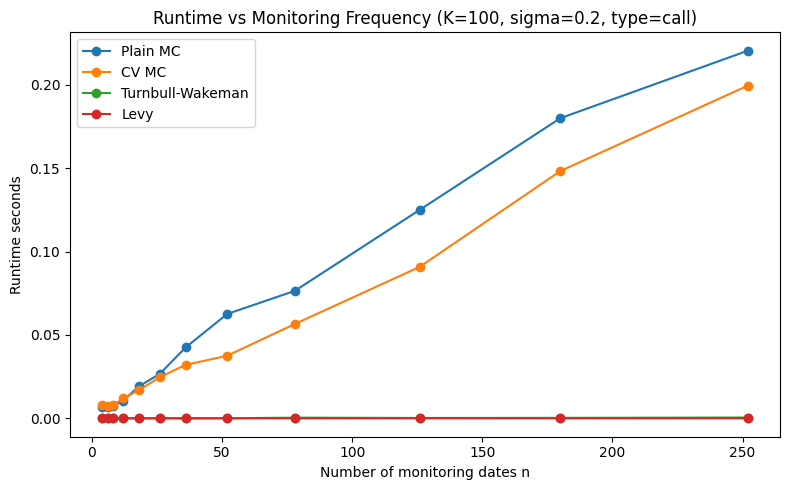

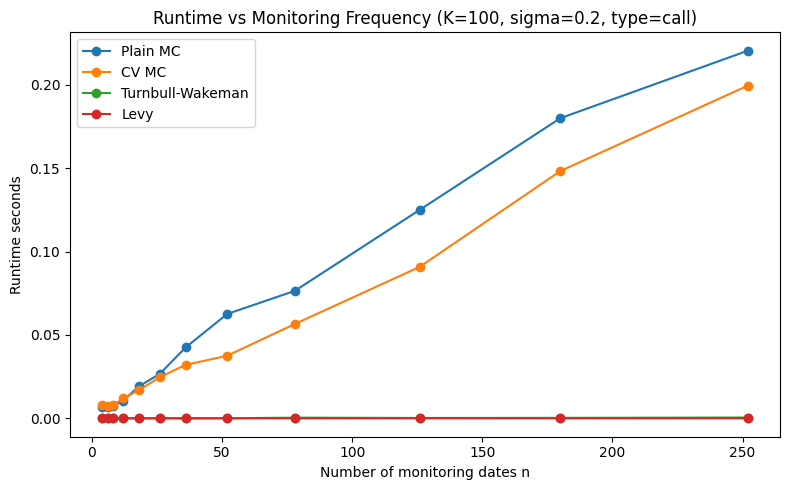

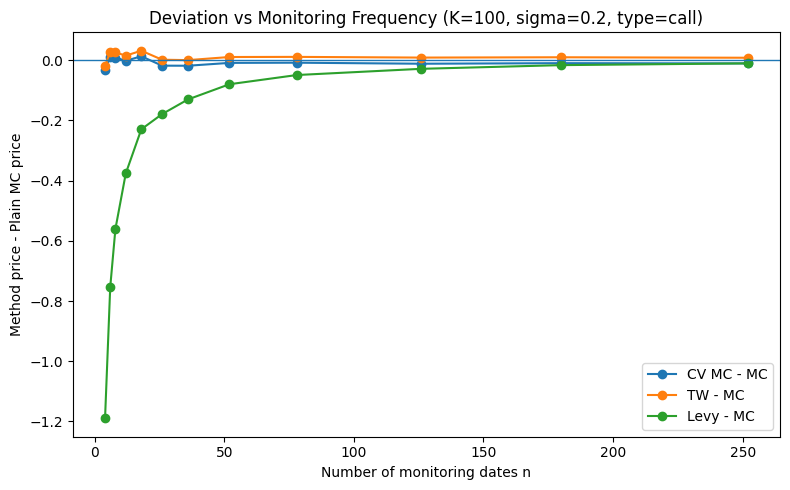

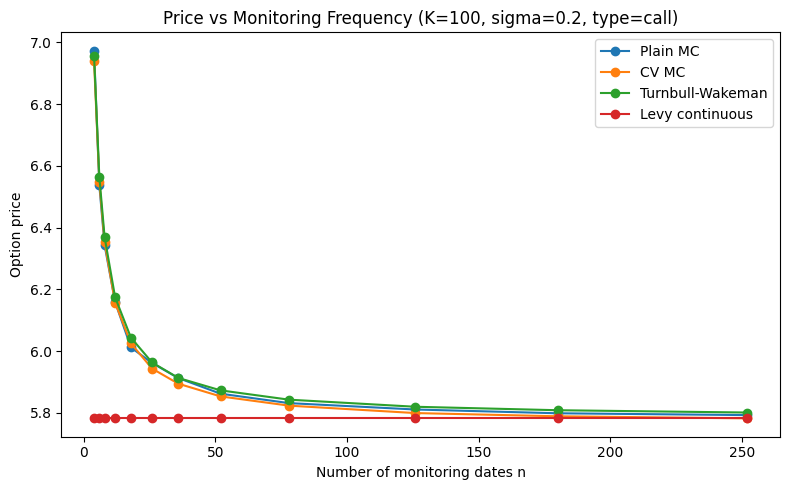

In [20]:
n_list = [4, 6, 8, 12, 18, 26, 36, 52, 78, 126, 180, 252]

df_n = run_grid_experiment(
    S0=100,
    r=0.05,
    T=1.0,
    K_list=[100],
    sigma_list=[0.2],
    n_list=n_list,
    n_paths=100000,
    seed=42,
    option_type="call",
)

df_n.head()

plot_runtime_vs_n(
    df_n,
    K_fixed=100,
    sigma_fixed=0.2,
    option_type="call",
)

plot_runtime_vs_n(
    df_n,
    K_fixed=100,
    sigma_fixed=0.2,
    option_type="call",
)

plot_error_vs_n(
    df_n,
    K_fixed=100,
    sigma_fixed=0.2,
    option_type="call",
)

plot_price_vs_n(
    df_n,
    K_fixed=100,
    sigma_fixed=0.2,
    option_type="call",
)

## 6. Compute and Plot Errors Relative to the CV Benchmark

In [16]:
benchmark_price = cv_result.price

pricing_results["Error vs CV"] = pricing_results["Price"] - benchmark_price
pricing_results["Absolute Error vs CV"] = pricing_results["Error vs CV"].abs()

pricing_results

TypeError: unsupported operand type(s) for -: 'GeometricAsianResult' and 'float'

In [ ]:
error_df = pricing_results[
    pricing_results["Method"] != "Control Variate MC"
].copy()

plt.figure(figsize=(9, 5))
plt.bar(error_df["Method"], error_df["Error vs CV"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Pricing Error Relative to CV")
plt.title("Pricing Error Relative to Control Variate Benchmark")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The Turnbull-Wakeman residual is defined as:

$$
\varepsilon_{\mathrm{TW}}
=
C_{\mathrm{TW}} - V_{\mathrm{CV}}.
$$

A positive residual means that Turnbull-Wakeman overprices the option relative to the control variate benchmark.  
A negative residual means that Turnbull-Wakeman underprices the option.

In [ ]:
tw_residual = tw_price - cv_result.price
scaled_residual = tw_residual / S0

print("TW Residual:", tw_residual)
print("Scaled TW Residual:", scaled_residual)

## 7. Load the Residual Dataset

In [ ]:
dataset_path = "tw_residual_dataset_s0_grid.csv"

df = pd.read_csv(dataset_path)

df.head()

In [ ]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

The dataset should contain option parameters, benchmark prices, Turnbull-Wakeman prices, residuals, and engineered features.

The target variable is the scaled residual:

$$
y
=
\frac{C_{\mathrm{TW}} - V_{\mathrm{CV}}}{S_0}.
$$

## 8. Construct Features and Target

In [ ]:
df = df.copy()

if "moneyness" not in df.columns:
    df["moneyness"] = df["K"] / df["S0"]

if "log_moneyness" not in df.columns:
    df["log_moneyness"] = np.log(df["K"] / df["S0"])

if "inv_n" not in df.columns:
    df["inv_n"] = 1.0 / df["n"]

if "inv_sqrt_n" not in df.columns:
    df["inv_sqrt_n"] = 1.0 / np.sqrt(df["n"])

if "scaled_residual" not in df.columns:
    df["scaled_residual"] = df["tw_residual"] / df["S0"]

In [ ]:
feature_cols = [
    "log_moneyness",
    "sigma",
    "T",
    "inv_n",
    "inv_sqrt_n",
]

target_col = "scaled_residual"

X = df[feature_cols]
y = df[target_col]

X.head()

## 9. Visualize the Residual Surface

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["moneyness"], df["scaled_residual"], alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Moneyness K / S0")
plt.ylabel("Scaled TW Residual")
plt.title("Scaled Turnbull-Wakeman Residual by Moneyness")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["sigma"], df["scaled_residual"], alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Volatility")
plt.ylabel("Scaled TW Residual")
plt.title("Scaled Turnbull-Wakeman Residual by Volatility")
plt.tight_layout()
plt.show()

These plots help show that the Turnbull-Wakeman error is not purely random.  
The residual changes systematically across the option parameter space, which makes residual learning meaningful.

## 10. Train a Polynomial Ridge Residual Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Scaled residual model performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

This model does not learn the full option price directly.  
Instead, it learns the remaining structured residual of the Turnbull-Wakeman approximation:

$$
\widehat{y}
=
f_{\theta}(x).
$$

The predicted scaled residual is then converted back to the original price scale:

$$
\widehat{\varepsilon}_{\mathrm{TW}}
=
S_0 \widehat{y}.
$$

## 11. Apply Bias Correction to One Option

In [ ]:
x_new = pd.DataFrame(
    {
        "log_moneyness": [np.log(K / S0)],
        "sigma": [sigma],
        "T": [T],
        "inv_n": [1.0 / n],
        "inv_sqrt_n": [1.0 / np.sqrt(n)],
    }
)

predicted_scaled_residual = model.predict(x_new)[0]
predicted_residual = S0 * predicted_scaled_residual

corrected_price = tw_price - predicted_residual

single_case_results = pd.DataFrame(
    {
        "Quantity": [
            "CV Benchmark",
            "Original TW Price",
            "Predicted Scaled Residual",
            "Predicted Residual",
            "Corrected TW Price",
            "Original TW Error",
            "Corrected TW Error",
        ],
        "Value": [
            cv_result.price,
            tw_price,
            predicted_scaled_residual,
            predicted_residual,
            corrected_price,
            tw_price - cv_result.price,
            corrected_price - cv_result.price,
        ],
    }
)

single_case_results

In [ ]:
single_plot_df = pd.DataFrame(
    {
        "Method": ["CV Benchmark", "Original TW", "Corrected TW"],
        "Price": [cv_result.price, tw_price, corrected_price],
    }
)

plt.figure(figsize=(7, 5))
plt.bar(single_plot_df["Method"], single_plot_df["Price"])
plt.ylabel("Option Price")
plt.title("Original TW vs Corrected TW")
plt.tight_layout()
plt.show()

The corrected Turnbull-Wakeman price is:

$$
C_{\mathrm{corrected}}
=
C_{\mathrm{TW}} - S_0 \widehat{y}.
$$

Equivalently:

$$
C_{\mathrm{corrected}}
=
C_{\mathrm{TW}} - \widehat{\varepsilon}_{\mathrm{TW}}.
$$

## 12. Apply Correction to the Test Set

In [ ]:
test_df = df.loc[X_test.index].copy()

test_df["predicted_scaled_residual"] = y_pred
test_df["predicted_residual"] = test_df["S0"] * test_df["predicted_scaled_residual"]

if "tw_price" in test_df.columns:
    tw_col = "tw_price"
elif "C_TW" in test_df.columns:
    tw_col = "C_TW"
else:
    raise ValueError("Cannot find TW price column. Expected 'tw_price' or 'C_TW'.")

if "cv_mc_price" in test_df.columns:
    cv_col = "cv_mc_price"
elif "V_CV" in test_df.columns:
    cv_col = "V_CV"
else:
    raise ValueError("Cannot find CV benchmark column. Expected 'cv_mc_price' or 'V_CV'.")

test_df["corrected_price"] = test_df[tw_col] - test_df["predicted_residual"]

test_df["original_error"] = test_df[tw_col] - test_df[cv_col]
test_df["corrected_error"] = test_df["corrected_price"] - test_df[cv_col]

test_df["original_abs_error"] = test_df["original_error"].abs()
test_df["corrected_abs_error"] = test_df["corrected_error"].abs()

test_df.head()

In [ ]:
original_mae = test_df["original_abs_error"].mean()
corrected_mae = test_df["corrected_abs_error"].mean()

original_rmse = (test_df["original_error"] ** 2).mean() ** 0.5
corrected_rmse = (test_df["corrected_error"] ** 2).mean() ** 0.5

improved_fraction = (
    test_df["corrected_abs_error"] < test_df["original_abs_error"]
).mean()

summary = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "Improved Fraction"],
        "Original TW": [original_mae, original_rmse, np.nan],
        "Corrected TW": [corrected_mae, corrected_rmse, improved_fraction],
        "Reduction": [
            1 - corrected_mae / original_mae,
            1 - corrected_rmse / original_rmse,
            np.nan,
        ],
    }
)

summary

## 13. Plot Original Error vs Corrected Error

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(test_df["original_error"], test_df["corrected_error"], alpha=0.6)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Original TW Error")
plt.ylabel("Corrected TW Error")
plt.title("Original Error vs Corrected Error")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(test_df[cv_col], test_df["corrected_price"], alpha=0.6)
min_price = min(test_df[cv_col].min(), test_df["corrected_price"].min())
max_price = max(test_df[cv_col].max(), test_df["corrected_price"].max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--", linewidth=1)
plt.xlabel("CV Benchmark Price")
plt.ylabel("Corrected TW Price")
plt.title("Corrected TW Price vs CV Benchmark")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(test_df["original_abs_error"], alpha=0.6, label="Original TW")
plt.hist(test_df["corrected_abs_error"], alpha=0.6, label="Corrected TW")
plt.xlabel("Absolute Pricing Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Pricing Errors")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Save Demo Results

In [ ]:
output_path = "demo_bias_correction_results.csv"

test_df.to_csv(output_path, index=False)

print("Saved demo results to:", output_path)

## 15. Interpretation

This demo shows the core idea of the project:

1. The Turnbull-Wakeman approximation gives a fast analytical price.
2. The control variate Monte Carlo price is used as a high-accuracy benchmark.
3. The residual between TW and CV is structured rather than random.
4. A polynomial Ridge model can learn this residual surface.
5. The corrected price keeps the speed of TW while improving accuracy within the calibrated parameter grid.

The correction should be interpreted mainly as an interpolation-based improvement.  
Performance may be weaker when extrapolating outside the training grid, especially for extreme moneyness or long maturity regimes.